<a href="https://colab.research.google.com/github/NamrathaBajjuri/AIML-TRAINING-TNSIF/blob/main/Presentation_Evaluation_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Presentation Evaluation Dashboard

### AI & ML Data Analysis Report

**Tools Used:**
- Python
- Pandas
- Matplotlib
- Google Colab

**Objective:**
Analyze the Presentation Evaluation Dataset by cleaning the data, calculating Total Marks, identifying top-performing students, and creating a dashboard with meaningful visualizations.

In [1]:
# Dashboard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [26]:
from google.colab import files
uploaded=files.upload()

Saving Presentation-TASK - Sheet1.csv to Presentation-TASK - Sheet1 (1).csv


In [27]:
df=pd.read_csv("Presentation-TASK - Sheet1.csv")
df.head()

,UID,Participant Name,Unnamed: 2,Project Name,Technical knowledge,Communication,Attrire,Marks
0,NaN,NaN,Group No,NaN,10,10.0,5.0,NaN
1,T160600201,Gayathri Munasu,3,"types of Data visuals,application",6,6.0,3.0,NaN
2,T160600202,Namratha Bajjuri,4,Comparision of t-SNE,6,6.0,4.0,NaN
3,T160600203,Nikitha Sambangi,NaN,NaN,NaN,NaN,NaN,NaN
4,T160600204,Akhil Reddy Komireddy,3,KNN,6,7.0,3.0,NaN


In [28]:
print("Shape of Dataset:",df.shape)
print("\nColumns")
print(df.columns)

Shape of Dataset: (85, 8)

Columns
Index(['UID', 'Participant Name', 'Unnamed: 2', 'Project Name',
       'Technical knowledge', 'Communication', 'Attrire', 'Marks'],
      dtype='object')


In [29]:
# Check missing values
print(df.isnull())

# Count missing values
df.isnull().sum() #count of missing values

      UID  Participant Name  Unnamed: 2  Project Name  Technical knowledge  \
0    True              True       False          True                False   
1   False             False       False         False                False   
2   False             False       False         False                False   
3   False             False        True          True                 True   
4   False             False       False         False                False   
..    ...               ...         ...           ...                  ...   
80  False             False        True          True                 True   
81   True             False        True          True                 True   
82   True              True        True          True                 True   
83  False             False        True          True                 True   
84   True             False        True          True                 True   

    Communication  Attrire  Marks  
0           False    False 

,0
UID,14
Participant Name,8
Unnamed: 2,23
Project Name,49
Technical knowledge,24
Communication,28
Attrire,30
Marks,85


In [31]:
# Rename the column
df = df.rename(columns={"Unnamed: 2": "Group No"})

# Remove the first row
df = df.iloc[1:].copy()

# Keep only rows where marks are available
columns = ["Technical knowledge", "Communication", "Attrire"]
df = df.dropna(subset=columns)

# Convert the marks columns to numeric
df[columns] = df[columns].apply(pd.to_numeric)

# Calculate total marks
df["Marks"] = df[columns].sum(axis=1)

# Display first five rows
df.head()

,UID,Participant Name,Group No,Project Name,Technical knowledge,Communication,Attrire,Marks
2,T160600202,Namratha Bajjuri,4,Comparision of t-SNE,6,6.0,4.0,16.0
4,T160600204,Akhil Reddy Komireddy,3,KNN,6,7.0,3.0,16.0
5,T160600205,CHARAN KONDA,3,"Applications of SVM ,",6,7.0,3.0,16.0
6,T160600206,Md Faisal,4,Functions,6,6.0,4.0,16.0
7,T160600207,BOPPANI BHARGAVI,2,Feature Engineering (numeric),8,7.0,4.0,19.0


In [32]:
# Summary statistics
df.describe()

,Technical knowledge,Communication,Attrire,Marks
count,53.000000,53.000000,53.000000,53.000000
mean,6.000000,6.037736,3.754717,15.792453
std,1.019049,0.919077,0.515366,1.935086
min,3.000000,3.000000,3.000000,10.000000
25%,5.000000,6.000000,3.000000,15.000000
50%,6.000000,6.000000,4.000000,16.000000
75%,7.000000,7.000000,4.000000,17.000000
max,8.000000,7.000000,5.000000,19.000000


In [34]:
# Summary Statistics

total_students = df.shape[0]
highest_marks = df["Marks"].max()
lowest_marks = df["Marks"].min()
average_marks = round(df["Marks"].mean(), 2)

highest_technical = df["Technical knowledge"].max()
highest_communication = df["Communication"].max()
highest_attire = df["Attrire"].max()

average_technical = round(df["Technical knowledge"].mean(), 2)
average_communication = round(df["Communication"].mean(), 2)
average_attire = round(df["Attrire"].mean(), 2)

print("Total Students :", total_students)
print("Highest Marks :", highest_marks)
print("Lowest Marks :", lowest_marks)
print("Average Marks :", average_marks)
print("Highest Technical :", highest_technical)
print("Highest Communication :", highest_communication)
print("Highest Attire :", highest_attire)
print("Average Technical :", average_technical)
print("Average Communication :", average_communication)
print("Average Attire :", average_attire)

Total Students : 53
Highest Marks : 19.0
Lowest Marks : 10.0
Average Marks : 15.79
Highest Technical : 8
Highest Communication : 7.0
Highest Attire : 5.0
Average Technical : 6.0
Average Communication : 6.04
Average Attire : 3.75


In [35]:
# Top 5 students
top_total = df.nlargest(5, 'Marks')
top_tech = df.nlargest(5, 'Technical knowledge')
top_comm = df.nlargest(5, 'Communication')
top_attire = df.nlargest(5, 'Attrire')

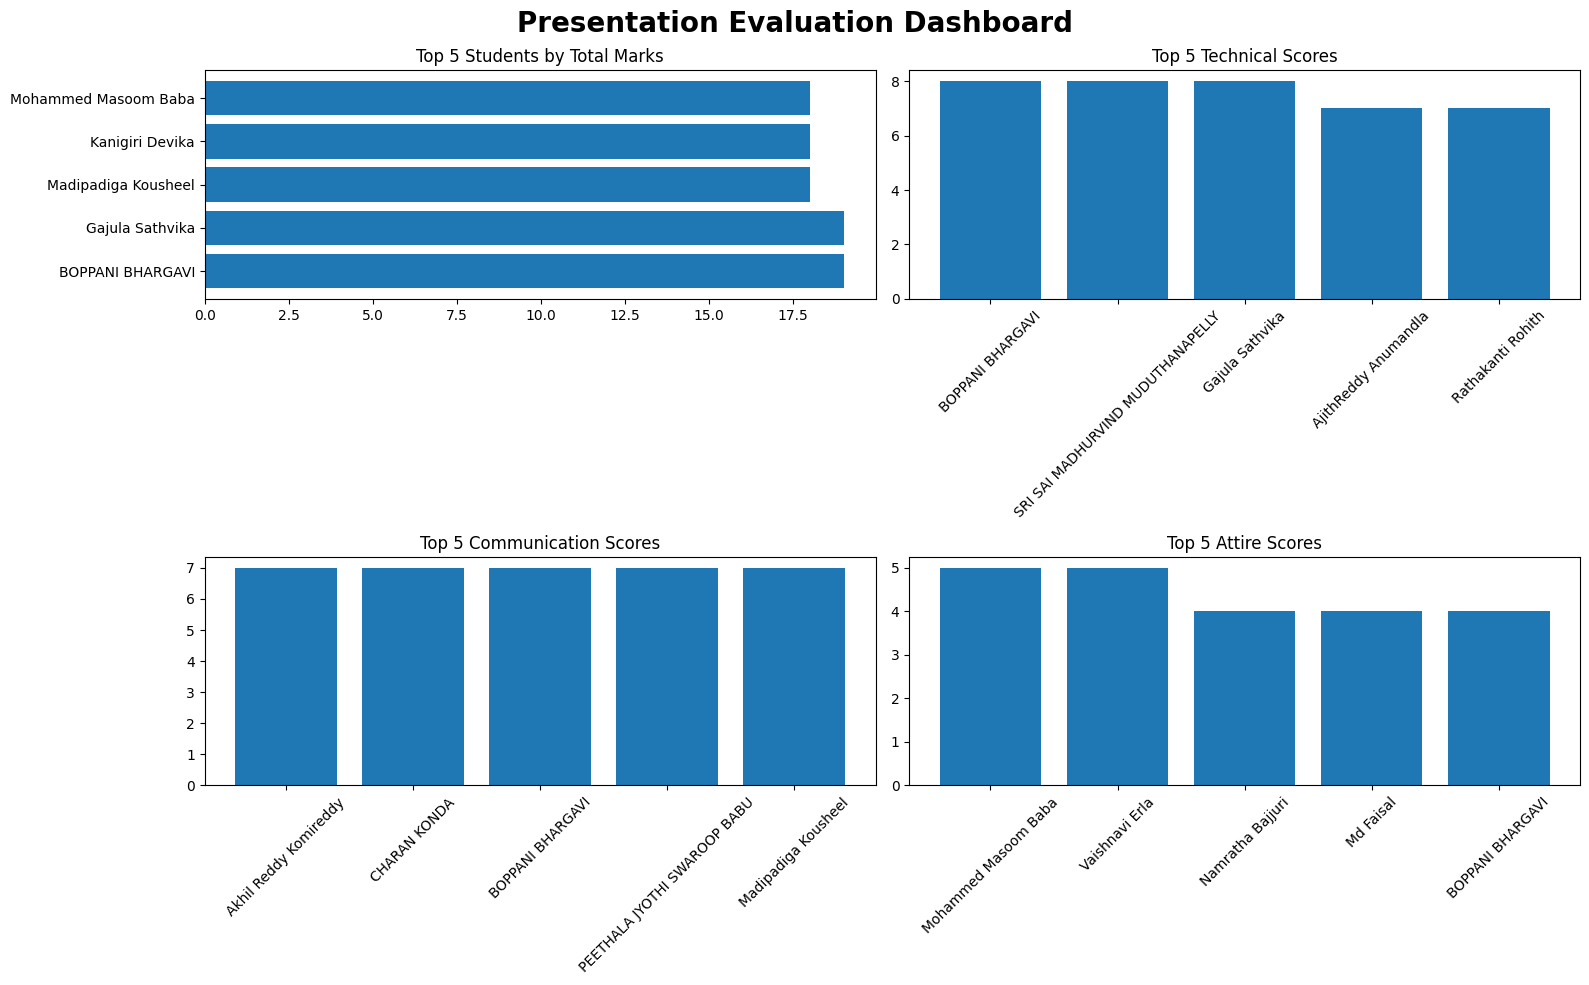

In [41]:
# Create Dashboard
fig = plt.figure(figsize=(16,10))
fig.suptitle("Presentation Evaluation Dashboard", fontsize=20, fontweight="bold")

# Top Total Marks
plt.subplot(2,2,1)
plt.barh(top_total['Participant Name'], top_total['Marks'])
plt.title('Top 5 Students by Total Marks')

# Technical
plt.subplot(2,2,2)
plt.bar(top_tech['Participant Name'], top_tech['Technical knowledge'])
plt.title('Top 5 Technical Scores')
plt.xticks(rotation=45)

# Communication
plt.subplot(2,2,3)
plt.bar(top_comm['Participant Name'], top_comm['Communication'])
plt.title('Top 5 Communication Scores')
plt.xticks(rotation=45)

# Attire
plt.subplot(2,2,4)
plt.bar(top_attire['Participant Name'], top_attire['Attrire'])
plt.title('Top 5 Attire Scores')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

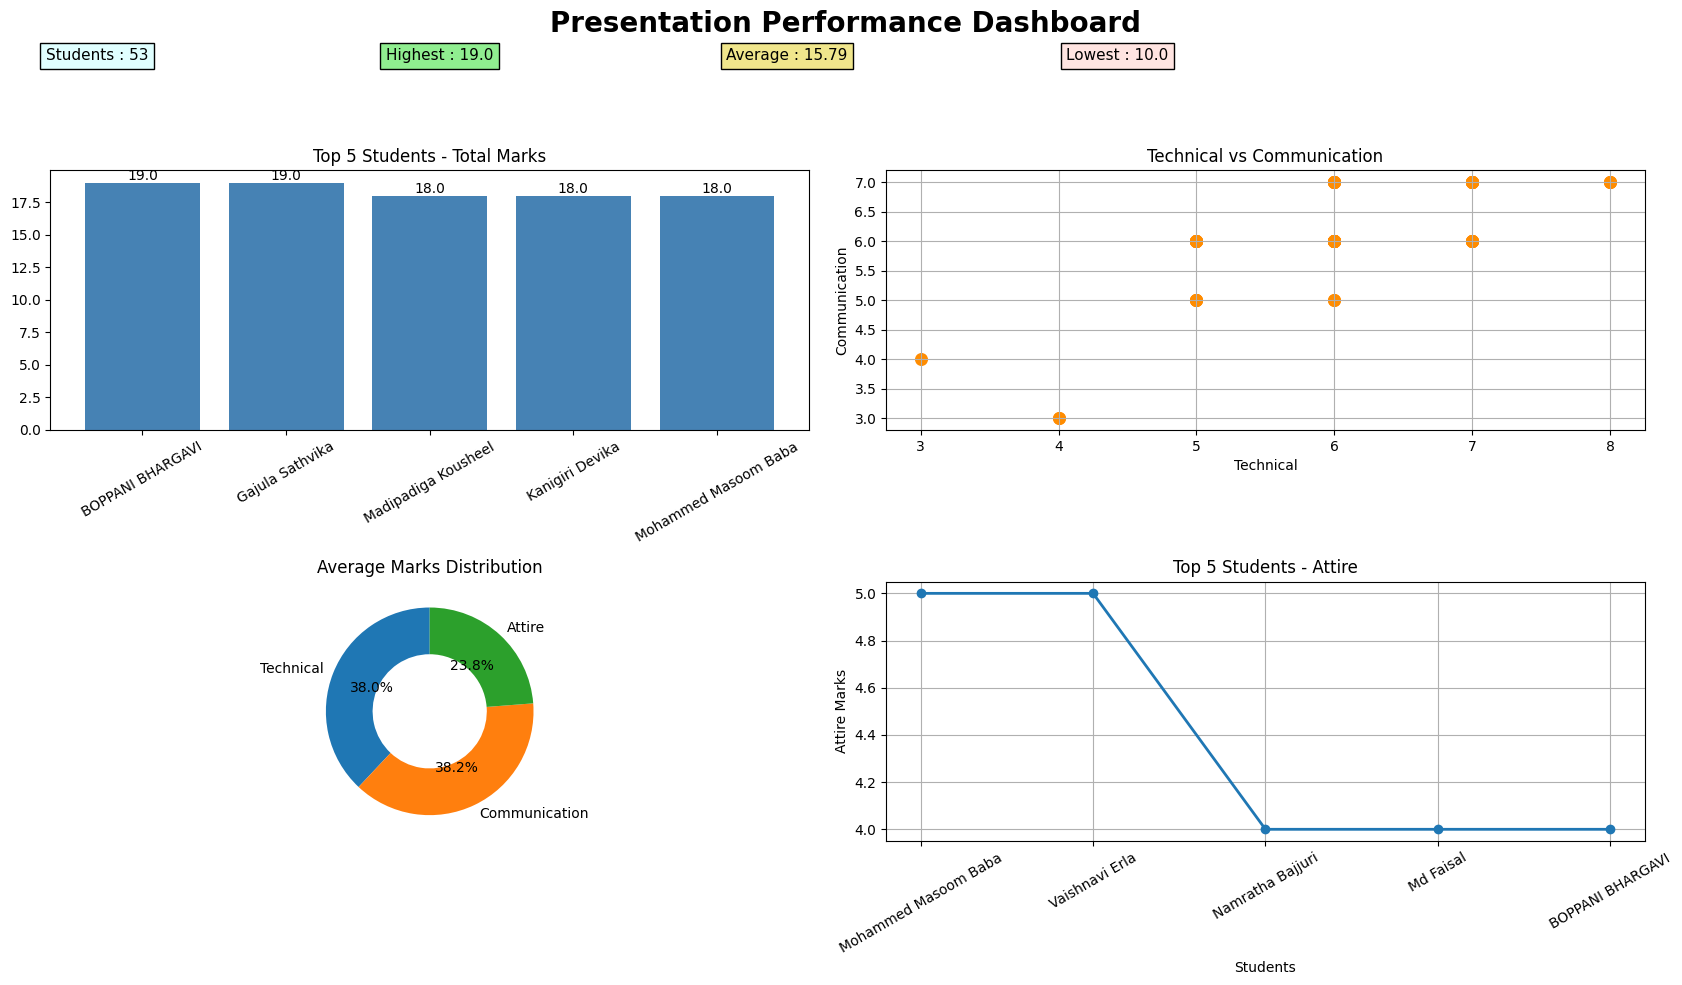

In [47]:
import matplotlib.pyplot as plt

# Top 5 data
top_total = df.nlargest(5, "Marks")
top_attire = df.nlargest(5, "Attrire")

# Average marks
avg_values = [
    df["Technical knowledge"].mean(),
    df["Communication"].mean(),
    df["Attrire"].mean()
]
labels = ["Technical", "Communication", "Attire"]

# Create Dashboard
fig, ax = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle("Presentation Performance Dashboard", fontsize=20, fontweight="bold")

# KPI Cards
fig.text(
    0.03, 0.93,
    f"Students : {total_students}",
    fontsize=11,
    bbox=dict(facecolor="lightcyan", edgecolor="black")
)

fig.text(
    0.23, 0.93,
    f"Highest : {highest_marks}",
    fontsize=11,
    bbox=dict(facecolor="lightgreen", edgecolor="black")
)

fig.text(
    0.43, 0.93,
    f"Average : {average_marks}",
    fontsize=11,
    bbox=dict(facecolor="khaki", edgecolor="black")
)

fig.text(
    0.63, 0.93,
    f"Lowest : {lowest_marks}",
    fontsize=11,
    bbox=dict(facecolor="mistyrose", edgecolor="black")
)

# 1. Bar Chart
ax[0,0].bar(
    top_total["Participant Name"],
    top_total["Marks"],
    color="steelblue"
)

ax[0,0].set_title("Top 5 Students - Total Marks")
ax[0,0].tick_params(axis="x", rotation=30)

for i, v in enumerate(top_total["Marks"]):
    ax[0,0].text(i, v+0.2, str(v), ha="center")

# 2. Scatter Plot
ax[0,1].scatter(
    df["Technical knowledge"],
    df["Communication"],
    s=70,
    color="darkorange"
)

ax[0,1].set_title("Technical vs Communication")
ax[0,1].set_xlabel("Technical")
ax[0,1].set_ylabel("Communication")
ax[0,1].grid(True)

# 3. Donut Chart
ax[1,0].pie(
    avg_values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

ax[1,0].set_title("Average Marks Distribution")

# 4. Line Chart
ax[1,1].plot(
    top_attire["Participant Name"],
    top_attire["Attrire"],
    marker="o",
    linewidth=2
)

ax[1,1].set_title("Top 5 Students - Attire")
ax[1,1].set_xlabel("Students")
ax[1,1].set_ylabel("Attire Marks")
ax[1,1].tick_params(axis="x", rotation=30)
ax[1,1].grid(True)

plt.tight_layout(rect=[0,0,1,0.90])

plt.savefig("Presentation_Performance_Dashboard.png", dpi=300)

plt.show()